# Exploratory Data Analysis

First we explore the dataset we are working with, SA1_K4_HS_MOZ, a HySpex hyperspectral cube.

The SA1 region, located in Dolina Dolnego Sanu Special Area of Conservation, is a study site within the Lower San River valley in Poland. Featuring a large river valley, agricultural land, and forest community. 

This notebook performs an initial inspection of the SA1 hyperspectral mosaic. It checks the ENVI metadata, visualizes a single wavelength band, inspects sample reflectance values, plots one pixel's spectral signature, estimates the region-wide mean spectrum, and samples pixels for a band-correlation view.


In [ ]:
from pathlib import Path
import gc
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spectral.io.envi as envi
from tqdm import tqdm


data_dir = Path("../data/SA1_K4")
HDR_PATH = data_dir / "MOZ/SA1_K4_HS_MOZ.hdr"
DAT_PATH = data_dir / "MOZ/SA1_K4_HS_MOZ.dat"

# set seed for reproducability
RNG = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


Image has resolution 6896 x 5496 x 430

wavelength range 0.416 - 2.396

In [2]:
hs_img = envi.open(str(HDR_PATH), str(DAT_PATH))
rows, cols, bands = hs_img.shape
wavelengths = np.array([float(w) for w in hs_img.metadata["wavelength"]], dtype=np.float32)

summary = pd.DataFrame(
    {
        "property": ["rows", "columns", "bands", "min_wavelength_um", "max_wavelength_um"],
        "value": [rows, cols, bands, wavelengths.min(), wavelengths.max()],
    }
)

summary


,property,value
0,rows,6896.00000
1,columns,5496.00000
2,bands,430.00000
3,min_wavelength_um,0.41618
4,max_wavelength_um,2.39644


### Single-Band Image Preview

Pixel location: 457 1679


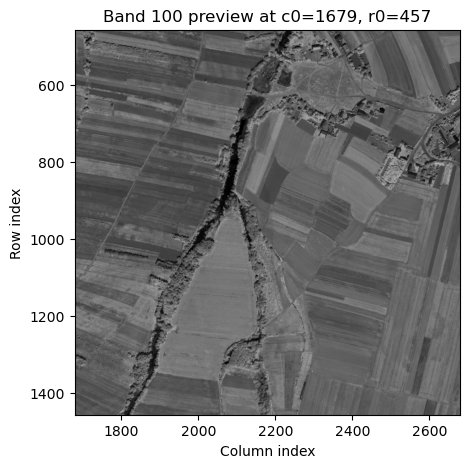

In [3]:
# Load ENVI map metadata.
meta = hs_img.metadata
map_info = meta["map info"]
x_start = float(map_info[3])
y_start = float(map_info[4])
x_res = float(map_info[5])
y_res = float(map_info[6])

# Sample target coordinates corresponding approximately to SA1_K4_RGB_701_324.
x_target = 701000
y_target = 325000

col = int((x_target - x_start) / x_res)
row = int((y_start - y_target) / y_res)
print("Pixel location:", row, col)

band_index = 100
height = 1000
width = 1000

r0 = max(row, 0)
c0 = max(col, 0)
r1 = min(row + height, rows)
c1 = min(col + width, cols)

band_img = hs_img[r0:r1, c0:c1, band_index]

plt.imshow(band_img, cmap="gray", extent=[c0, c1, r1, r0])
plt.title(f"Band {band_index} preview at c0={c0}, r0={r0}")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.grid(False)
plt.show()


Taking a look at the raw values that this data contains. Each point is a single value, measuring the reflectance of that specific band at a specific location. In this case, we take a look at band index 100


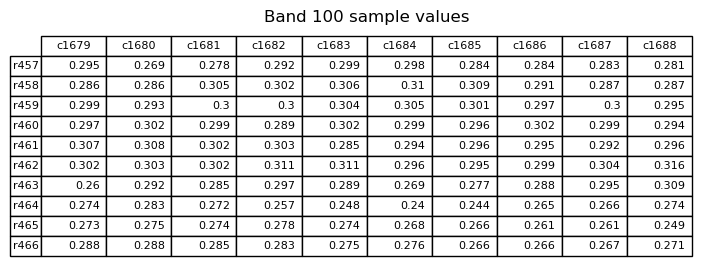

In [4]:
top_left_subset = np.array(hs_img[r0:r0 + 10, c0:c0 + 10, band_index]).squeeze()

row_labels = [f"r{i}" for i in range(r0, r0 + top_left_subset.shape[0])]
col_labels = [f"c{j}" for j in range(c0, c0 + top_left_subset.shape[1])]

fig, ax = plt.subplots(figsize=(7, 3))
ax.axis("off")

table = ax.table(
    cellText=np.round(top_left_subset, 3),
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.2)

plt.title(f"Band {band_index} sample values")
plt.show()


## Spectral Signature at One Pixel

The full dataset contains 430 bands of reflectance. When plotted together, we see the wavlength distribution for the selected sample pixel. The shaded regions separate visible, near-infrared, and shortwave-infrared wavelengths.


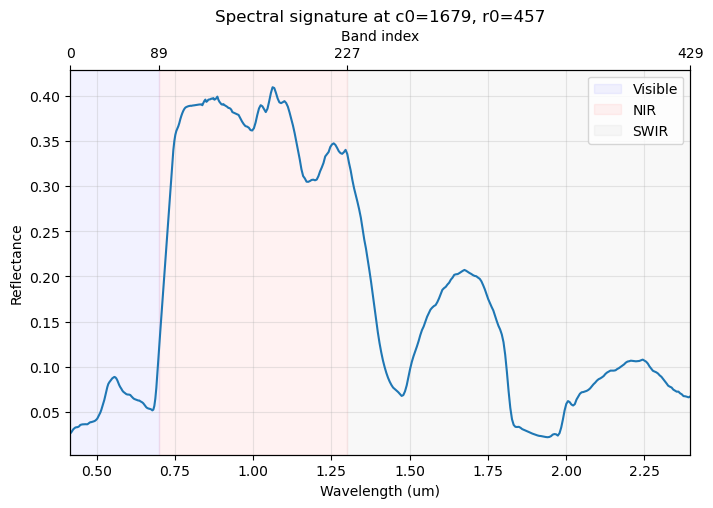

In [14]:
signature = hs_img[r0, c0, :]
reflectance = signature.flatten()

fig, ax = plt.subplots()

ax.plot(wavelengths, reflectance)
ax.set_title(f"Spectral signature at c0={c0}, r0={r0}")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Reflectance")

regions = [
    ("Visible", 0.4, 0.7, "blue"),
    ("NIR", 0.7, 1.3, "red"),
    ("SWIR", 1.3, 2.5, "gray"),
]

for label, start, end, color in regions:
    ax.axvspan(start, end, color=color, alpha=0.05, label=label)

ax.set_xlim(wavelengths.min(), wavelengths.max())

# Grid follows wavelength axis only.
ax.grid(True, axis="x", alpha=0.3)
ax.grid(True, axis="y", alpha=0.3)

# Top axis: include first/last band plus spectral-region boundaries.
boundary_wavelengths = np.array([0.4, 0.7, 1.3, 2.5])
boundary_wavelengths = boundary_wavelengths[
    (boundary_wavelengths >= wavelengths.min()) &
    (boundary_wavelengths <= wavelengths.max())
]

boundary_band_indices = [
    int(np.argmin(np.abs(wavelengths - wl)))
    for wl in boundary_wavelengths
]

tick_indices = [0] + boundary_band_indices + [len(wavelengths) - 1]
tick_indices = sorted(set(tick_indices))

tick_positions = [wavelengths[i] for i in tick_indices]
tick_labels = [str(i) for i in tick_indices]

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(tick_positions)
ax2.set_xticklabels(tick_labels)
ax2.set_xlabel("Band index")

ax2.grid(False)

ax.legend()
plt.show()

### Region-Wide Mean Spectrum

Compute the mean and standard deviation for every wavelength band across the full SA1 mosaic

In [ ]:
mean_reflectance = np.zeros(bands, dtype=np.float64)
std_reflectance = np.zeros(bands, dtype=np.float64)

print(f"Calculating region mean and standard deviation for {bands} bands...")

# band_data holds one full hyperspectral band in memory
# delete after each iteration to stop from loading entire image into memory
for band in tqdm(range(bands), desc="Processing bands", unit="band", file=sys.stdout):
    band_data = hs_img.read_band(band).astype(np.float64, copy=False)
    mean_reflectance[band] = band_data.mean()
    std_reflectance[band] = band_data.std()
    del band_data

gc.collect()


Calculating region mean and standard deviation for 430 bands...
Processing bands: 100%|██████████| 430/430 [02:59<00:00,  2.39band/s]


5187

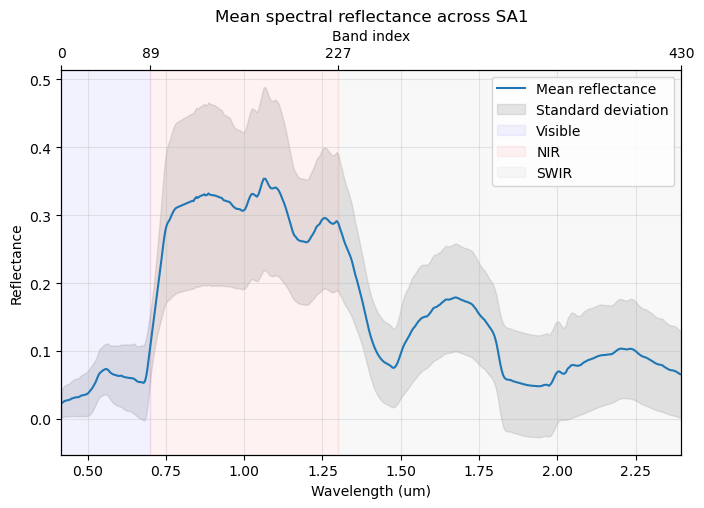

In [15]:
fig, ax = plt.subplots()

ax.plot(wavelengths, mean_reflectance, label="Mean reflectance")
ax.fill_between(
    wavelengths,
    mean_reflectance - std_reflectance,
    mean_reflectance + std_reflectance,
    color="gray",
    alpha=0.2,
    label="Standard deviation",
)

ax.set_title("Mean spectral reflectance across SA1")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Reflectance")

regions = [
    ("Visible", 0.4, 0.7, "blue"),
    ("NIR", 0.7, 1.3, "red"),
    ("SWIR", 1.3, 2.5, "gray"),
]

for label, start, end, color in regions:
    ax.axvspan(start, end, color=color, alpha=0.05, label=label)

ax.set_xlim(wavelengths.min(), wavelengths.max())

# Grid follows wavelength axis only.
ax.grid(True, axis="x", alpha=0.3)
ax.grid(True, axis="y", alpha=0.3)

# Top axis: first/last band plus spectral-region boundaries.
boundary_wavelengths = np.array([0.4, 0.7, 1.3, 2.5])
boundary_wavelengths = boundary_wavelengths[
    (boundary_wavelengths >= wavelengths.min()) &
    (boundary_wavelengths <= wavelengths.max())
]

boundary_band_indices = [
    int(np.argmin(np.abs(wavelengths - wl)))
    for wl in boundary_wavelengths
]

tick_indices = [0] + boundary_band_indices + [len(wavelengths) - 1]
tick_indices = sorted(set(tick_indices))

tick_positions = [wavelengths[i] for i in tick_indices]

# Display final label as band count, e.g. 430, while using zero-based index internally.
tick_labels = [
    str(i if i < len(wavelengths) - 1 else len(wavelengths))
    for i in tick_indices
]

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(tick_positions)
ax2.set_xticklabels(tick_labels)
ax2.set_xlabel("Band index")

ax2.grid(False)

ax.legend()
plt.show()

### Band Correlation Sample

Sample 1 out of 1000 pixels, from across the mosaic to estimate band-to-band correlation without loading the entire image into RAM.


In [ ]:
mm = hs_img.open_memmap()
rows, cols, bands = mm.shape

n_samples = 10000
sample_idx = RNG.choice(rows * cols, size=n_samples, replace=False)

X = mm.reshape(-1, bands)[sample_idx].astype(np.float32)

del mm
gc.collect()


7081

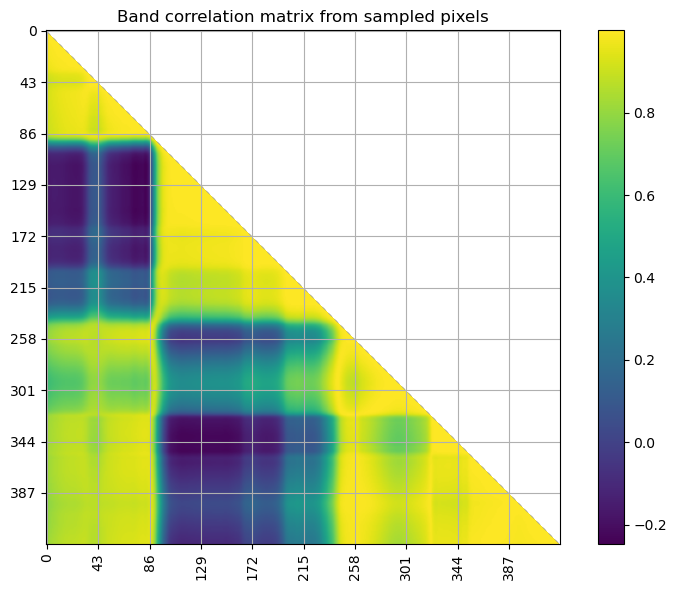

In [9]:
corr = np.corrcoef(X, rowvar=False)

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = np.ma.masked_where(mask, corr)

step = max(1, bands // 10)
ticks = np.arange(0, bands, step)

ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(ticks, rotation=90)
ax.set_yticklabels(ticks)

im = ax.imshow(corr_masked)

if bands <= 20:
    for i in range(bands):
        for j in range(bands):
            ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=6)

fig.colorbar(im)
plt.title("Band correlation matrix from sampled pixels")
plt.tight_layout()
plt.show()
